## **1. Análisis Exploratorio de Datos (EDA)**
**Objetivo:** comprender la estructura del dataset musical, identificar patrones, detectar anomalías y limpiar los datos para preparar el terreno hacia el modelado.

In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Carga del dataset
df = pd.read_csv('data/SpotifyFeatures.csv')

# Vista previa del dataset
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [19]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

Tras una primera inspección con `.info()`, destacamos los siguientes puntos clave sobre la calidad del dato:

* **Volumen:** el dataset contiene **232725 entradas** y 18 columnas.
* **Completitud: no existen valores nulos**. Esto simplifica el preprocesamiento al eliminar la necesidad de técnicas de imputación.
* **Tipología:**
    * **Variables numéricas:** (`float64`, `int64`) como *acousticness* o *popularity*.
    * **Variables categóricas:** (`object`) como *key*, *mode* y *genre*.
    
Las variables categóricas requerirán una transformación (Encoding) posterior, ya que los algoritmos de Machine Learning operan exclusivamente con vectores numéricos.

In [20]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity,232725.0,41.127502,18.189948,0.00000,29.0000,43.000000,55.0000,100.000
acousticness,232725.0,0.368560,0.354768,0.00000,0.0376,0.232000,0.7220,0.996
danceability,232725.0,0.554364,0.185608,0.05690,0.4350,0.571000,0.6920,0.989
duration_ms,232725.0,235122.339306,118935.909299,15387.00000,182857.0000,220427.000000,265768.0000,5552917.000
energy,232725.0,0.570958,0.263456,0.00002,0.3850,0.605000,0.7870,0.999
instrumentalness,232725.0,0.148301,0.302768,0.00000,0.0000,0.000044,0.0358,0.999
liveness,232725.0,0.215009,0.198273,0.00967,0.0974,0.128000,0.2640,1.000
loudness,232725.0,-9.569885,5.998204,-52.45700,-11.7710,-7.762000,-5.5010,3.744
speechiness,232725.0,0.120765,0.185518,0.02220,0.0367,0.050100,0.1050,0.967
tempo,232725.0,117.666585,30.898907,30.37900,92.9590,115.778000,139.0540,242.903


Las estadísticas revelan una **disparidad significativa en las magnitudes** de las variables, lo cual es crítico para modelos basados en distancia:

* **Rango 0-1:** `acousticness`, `danceability`, `energy`.
* **Rango 0-100:** `popularity`.
* **Escala logarítmica:** `loudness` (dB) oscila entre -52 y 3.7.
* **Gran magnitud:** `duration_ms` tiene una media de ~235k y máximos de 5.5M.

Esta varianza confirma la **necesidad imperativa de aplicar técnicas de normalización o estandarización**. Sin normalización, la variable `duration_ms` dominaría completamente el cálculo de la distancia euclídea, haciendo que el modelo ignore características sutiles como la `danceability`.

Antes de continuar, debemos validar la **unicidad de las instancias**. Dado que este dataset agrega canciones de distintas playlists temáticas, existe el riesgo de que una misma canción popular aparezca etiquetada bajo múltiples géneros (ej: 'Pop' y 'Dance' a la vez).

**Hipótesis:** existen múltiples filas compartiendo el mismo `track_id`, lo cual generaría sesgo en el modelo.

In [21]:
# Calculo de duplicados
total_filas = df.shape[0]
canciones_unicas = df['track_id'].nunique()
canciones_duplicadas = total_filas - canciones_unicas

print(f"Total de registros: {total_filas}")
print(f"Canciones únicas (track_id): {canciones_unicas}")
print(f"Canciones duplicadas: {canciones_duplicadas}")

# Mostrar evidencia. Si hay canciones duplicadas, buscamos un ID repetido para visualizarlo
if canciones_duplicadas > 0:
    # Obtenemos el ID más frecuente
    id_repetido = df['track_id'].value_counts().idxmax()
    print(f"\nEjemplo de duplicidad para el track_id: {id_repetido}")
    display(df[df['track_id'] == id_repetido])

Total de registros: 232725
Canciones únicas (track_id): 176774
Canciones duplicadas: 55951

Ejemplo de duplicidad para el track_id: 3R73Y7X53MIQZWnKloWq5i


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
5506,Alternative,Toro y Moi,Monte Carlo (feat. WET),3R73Y7X53MIQZWnKloWq5i,50,0.0821,0.653,125133,0.381,0.000073,C#,0.175,-8.967,Major,0.0512,140.08,4/4,0.133
15615,Dance,Toro y Moi,Monte Carlo (feat. WET),3R73Y7X53MIQZWnKloWq5i,61,0.0821,0.653,125133,0.381,0.000073,C#,0.175,-8.967,Major,0.0512,140.08,4/4,0.133
41367,Folk,Toro y Moi,Monte Carlo (feat. WET),3R73Y7X53MIQZWnKloWq5i,61,0.0821,0.653,125133,0.381,0.000073,C#,0.175,-8.967,Major,0.0512,140.08,4/4,0.133
55106,R&B,Toro y Moi,Monte Carlo (feat. WET),3R73Y7X53MIQZWnKloWq5i,61,0.0821,0.653,125133,0.381,0.000073,C#,0.175,-8.967,Major,0.0512,140.08,4/4,0.133
77769,Children’s Music,Toro y Moi,Monte Carlo (feat. WET),3R73Y7X53MIQZWnKloWq5i,61,0.0821,0.653,125133,0.381,0.000073,C#,0.175,-8.967,Major,0.0512,140.08,4/4,0.133
94721,Indie,Toro y Moi,Monte Carlo (feat. WET),3R73Y7X53MIQZWnKloWq5i,61,0.0821,0.653,125133,0.381,0.000073,C#,0.175,-8.967,Major,0.0512,140.08,4/4,0.133
149585,Pop,Toro y Moi,Monte Carlo (feat. WET),3R73Y7X53MIQZWnKloWq5i,61,0.0821,0.653,125133,0.381,0.000073,C#,0.175,-8.967,Major,0.0512,140.08,4/4,0.133
225238,Rock,Toro y Moi,Monte Carlo (feat. WET),3R73Y7X53MIQZWnKloWq5i,61,0.0821,0.653,125133,0.381,0.000073,C#,0.175,-8.967,Major,0.0512,140.08,4/4,0.133


Se ha confirmado la existencia de miles de canciones repetidas. 

**Decisión:** para evitar el *data leakage* (fugas de datos) y el sobreajuste, vamos a eliminar los duplicados conservando solo la primera aparición de cada canción. 

**Justificación:** nuestro sistema de recomendación se basará en **similitud de audio**. Si mantenemos múltiples copias de la misma canción:
1. El análisis exploratorio (histogramas, medias) estará distorsionado por las canciones populares repetidas.
2. El modelo (KNN) podría recomendar la misma canción 5 veces (con distinta etiqueta de género) al buscar "vecinos cercanos", arruinando la experiencia de usuario.

In [22]:
# Eliminación de duplicados manteniendo la primera aparición
df_clean = df.drop_duplicates(subset=['track_id'], keep='first')

# Verificación de la eliminación de duplicados
print(f"Dimensiones antes: {df.shape}")
print(f"Dimensiones después: {df_clean.shape}")

Dimensiones antes: (232725, 18)
Dimensiones después: (176774, 18)


Una vez limpio el dataset, analizamos la distribución de las características musicales cualitativas para entender el sesgo de nuestra "biblioteca musical". Para ello, las dividimos en dos grupos:
1. **Características musicales (Baja cardinalidad):** `genre`, `key`, `mode` y `time_signature`.
2. **Metadatos (Alta cardinalidad):** `artist_name`.

> **Nota:** Variables como `track_id` o `track_name` se excluyen de la visualización por ser identificadores únicos o textos libres con demasiada variabilidad (alta cardinalidad) para un análisis de frecuencia útil.

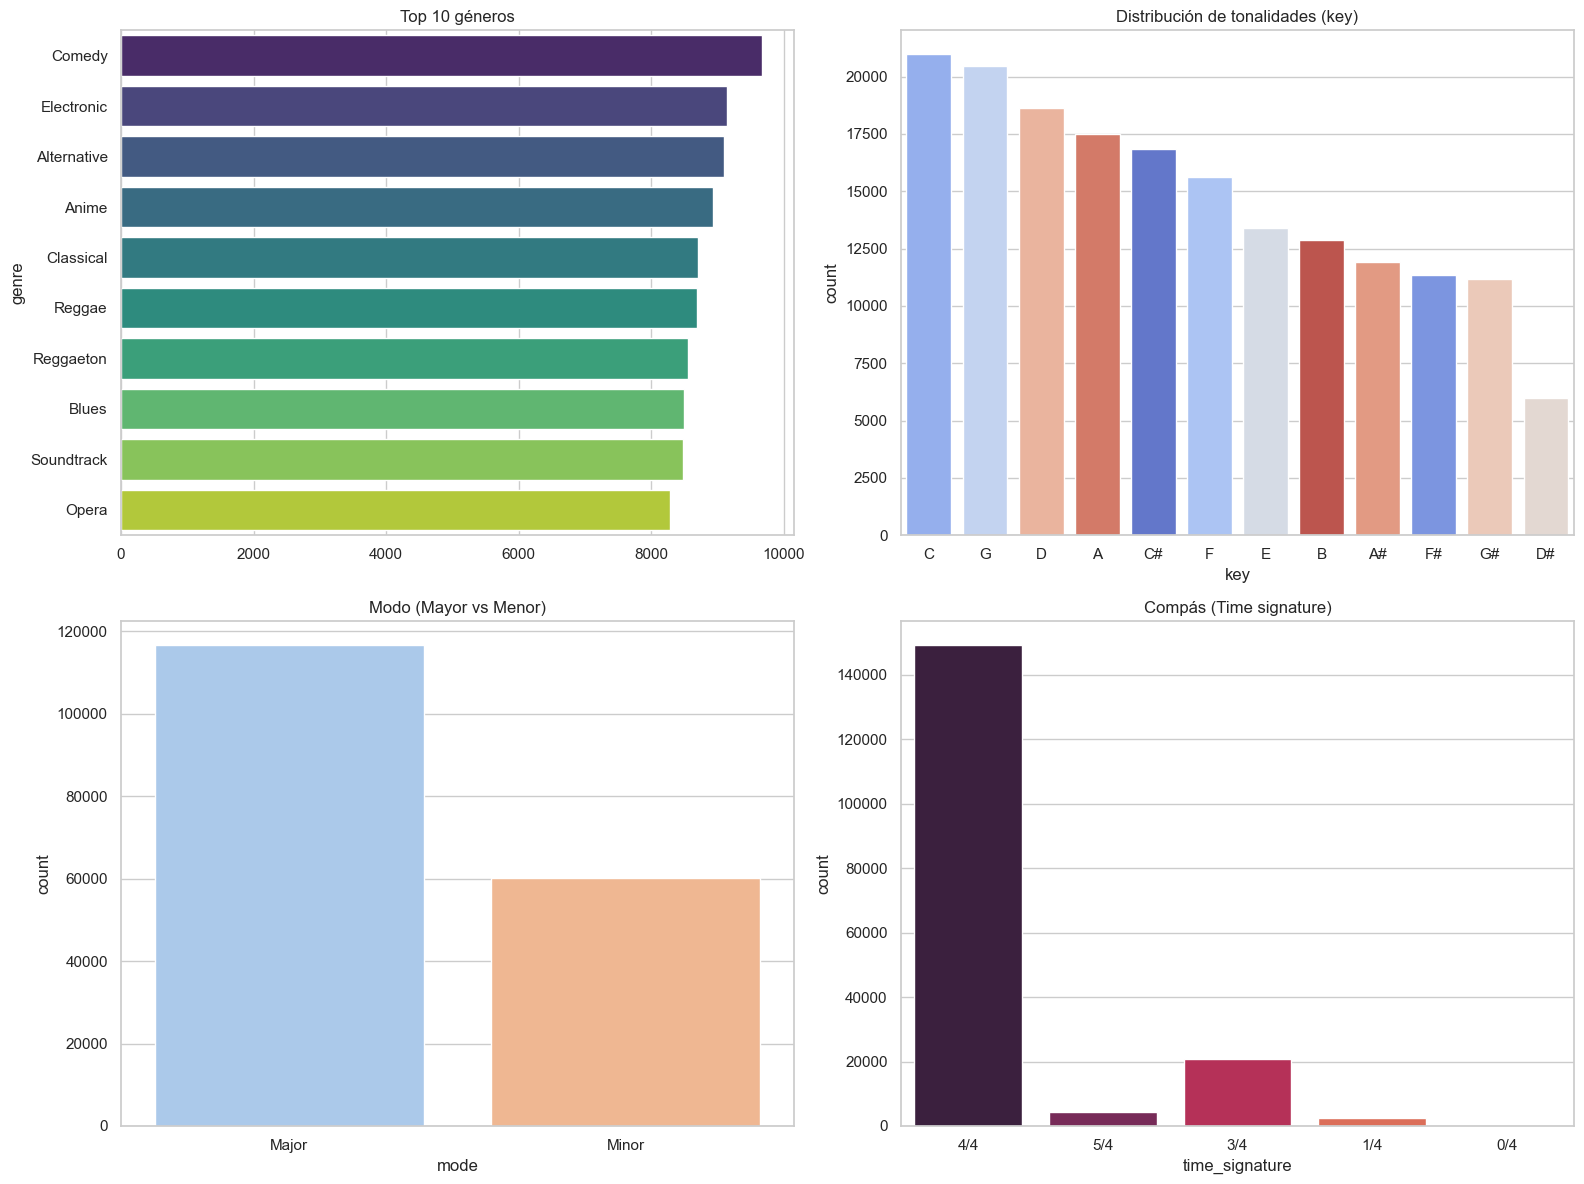

In [23]:
# Configuración: 2 filas, 2 columnas
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de géneros (Top 10)
top_genres = df_clean['genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, legend=False, ax=ax[0,0], palette='viridis')
ax[0,0].set_title('Top 10 géneros')

# 2. Distribución de tonalidades (key)
sns.countplot(data=df_clean, x='key', hue='key', legend=False, ax=ax[0,1], 
              order=df_clean['key'].value_counts().index, palette='coolwarm')
ax[0,1].set_title('Distribución de tonalidades (key)')

# 3. Distribución de modo (Mayor/Menor)
sns.countplot(data=df_clean, x='mode', hue='mode', legend=False, ax=ax[1,0], palette='pastel')
ax[1,0].set_title('Modo (Mayor vs Menor)')

# 4. Distribución de compás (Time signature)
sns.countplot(data=df_clean, x='time_signature', hue='time_signature', legend=False, ax=ax[1,1], palette='rocket')
ax[1,1].set_title('Compás (Time signature)')

plt.tight_layout()
plt.show()

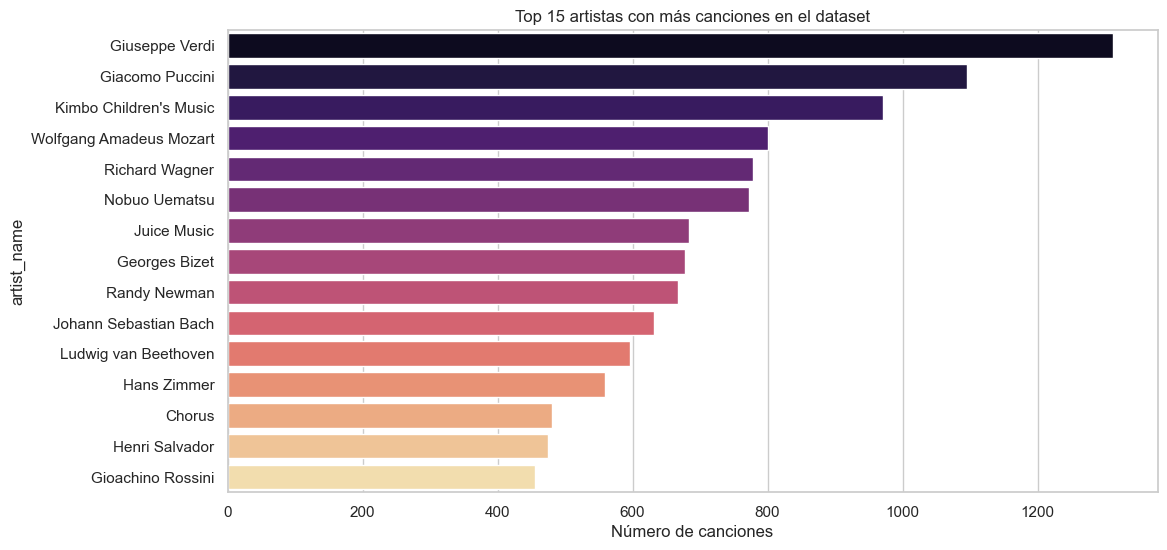

In [24]:
# Análisis de artistas (Variable de alta cardinalidad)
plt.figure(figsize=(12, 6))
top_artists = df_clean['artist_name'].value_counts().head(15)

sns.barplot(x=top_artists.values, y=top_artists.index, hue=top_artists.index, legend=False, palette='magma')
plt.title('Top 15 artistas con más canciones en el dataset')
plt.xlabel('Número de canciones')
plt.show()


Tras estos análisis, podemos interpretar:

1.  **Sesgo de géneros:** observamos que ciertos géneros específicos dominan el dataset. Esto implica que el modelo tendrá más "conocimiento" sobre estos estilos y será más preciso recomendándolos que en los géneros minoritarios.
2.  **Validación musical (Key):** el predominio de las tonalidades **C (Do)** y **G (Sol)** valida la calidad de los datos, ya que coincide con las tonalidades más comunes en la composición de música popular occidental.
3.  **Ambiente general (Mode):** la mayoría de canciones (~65%) están en **Modo Mayor**, lo que sugiere un catálogo con tendencia hacia sonoridades "brillantes" o "positivas".
4.  **Baja varianza en compás:** la variable `time_signature` es casi constante (4/4). Al no aportar diferenciación entre canciones, es una candidata firme a ser **eliminada** del modelo final para reducir ruido.

A continuación, analizaremos la relación matemática entre las variables de audio cuantitativas.
* **Objetivo:** detectar multicolinealidad (variables redundantes) que puedan ensuciar el modelo de distancia. Si dos variables tienen una correlación cercana a 1 (o -1), el modelo estará "contando doble" esa característica.

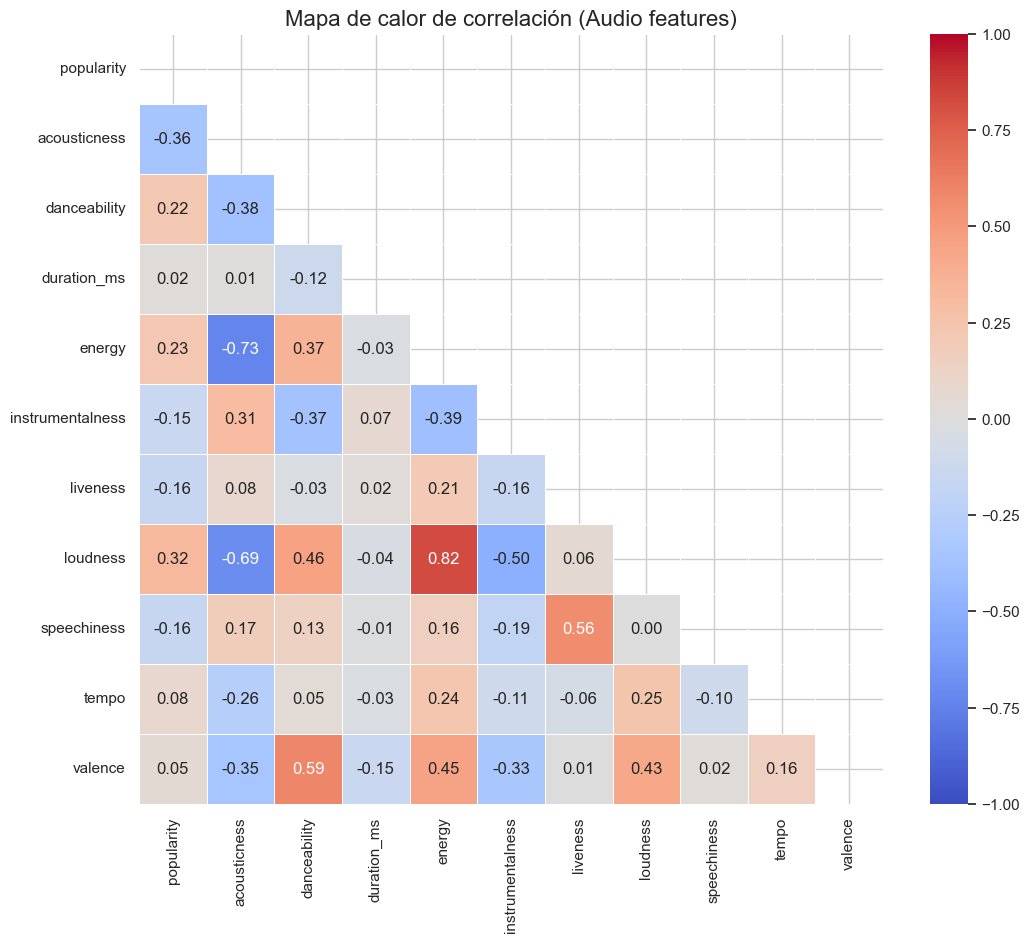

In [25]:
# Selección de columnas numéricas (excluimos las categóricas)
numeric_cols = ['popularity', 'acousticness', 'danceability', 'duration_ms', 
                'energy', 'instrumentalness', 'liveness', 'loudness', 
                'speechiness', 'tempo', 'valence']

# Cálculo de la matriz de correlación
# Usamos el método de Pearson (estándar para relaciones lineales)
corr_matrix = df_clean[numeric_cols].corr()

# Visualización con Heatmap
plt.figure(figsize=(12, 10))
# Usamos una máscara para tapar la diagonal superior (es redundante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)

plt.title('Mapa de calor de correlación (Audio features)', fontsize=16)
plt.show()

**Hallazgos clave en la correlación:**

1.  **Energy vs Loudness (+0.82):** existe una correlación positiva extremademente alta.
    * *Significado:* las canciones ruidosas (dB altos) casi siempre tienen mucha energía.
    * *Decisión de modelado:* al ser tan redundantes, mantener ambas podría dar un peso excesivo a la "potencia" de la canción en el cálculo de distancias. Valoraremos eliminar `loudness` o usar PCA.

2.  **Acousticness vs Energy (-0.73):** correlación negativa fuerte.
    * *Significado:* cuanto más acústica es una canción, menos energía electrónica tiene. Esto es lógico y deseable para diferenciar géneros como Folk vs Techno.

3.  **Valence vs Danceability (+0.59):**
    * *Significado:* las canciones bailables tienden a ser más positivas/alegres. Es una relación fuerte pero no absoluta (existen canciones tristes bailables), por lo que ambas variables aportan matices útiles.

Para finalizar el EDA, buscamos valores extremos que puedan distorsionar el modelo.
* **Tempo:** verificamos que no existan errores (0 BPM).
* **Duración (`duration_ms`):** buscamos canciones excesivamente largas (posibles sesiones de DJ o podcasts) que no deberían compararse con canciones estándar.

Tempo mínimo detectado: 30.379 BPM
Tempo máximo detectado: 242.903 BPM


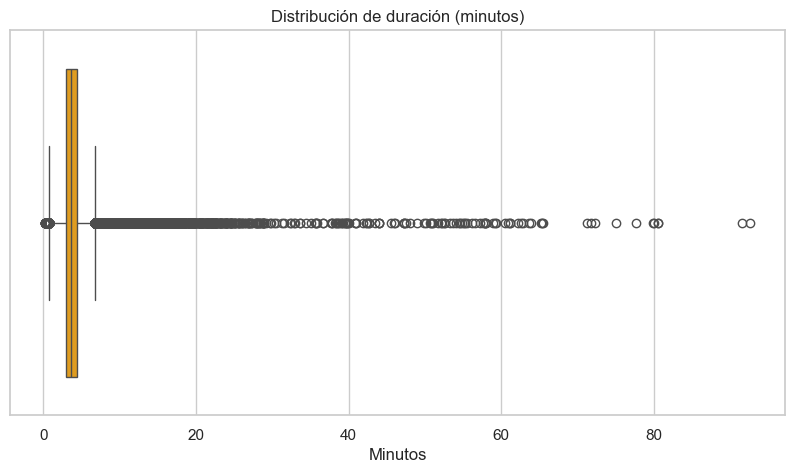

Canciones de más de 10 minutos: 2052


In [26]:
# Verificación de Tempo (Solo validación)
print(f"Tempo mínimo detectado: {df_clean['tempo'].min()} BPM")
print(f"Tempo máximo detectado: {df_clean['tempo'].max()} BPM")

# Visualización de Duración
plt.figure(figsize=(10, 5))
# Convertimos a minutos para facilitar la lectura
duration_mins = df_clean['duration_ms'] / 60000 
sns.boxplot(x=duration_mins, color='orange')
plt.title('Distribución de duración (minutos)')
plt.xlabel('Minutos')
plt.show()

# Conteo de casos extremos
print(f"Canciones de más de 10 minutos: {len(df_clean[duration_mins > 10])}")

**Análisis de anomalías:**

1.  **Tempo:** el rango de tempo es correcto (mínimo ~30 BPM), por lo que no se requiere limpieza en esta variable.
2.  **Duración:** el gráfico de caja muestra una cola de *outliers* extremos (puntos negros a la derecha). Existen más de 2000 pistas que superan los 10 minutos. 
    * *Acción:* Limitaremos el dataset a canciones de **máximo 10 minutos** para homogeneizar la muestra y evitar que la duración domine el cálculo de similitud.

In [27]:
# Definir límites lógicos (Solo duración)
MIN_DURATION = 30000   # 30 segundos (evitamos intros muy cortas)
MAX_DURATION = 600000  # 10 minutos

# Aplicar filtrado
df_final = df_clean[
    (df_clean['duration_ms'] >= MIN_DURATION) &
    (df_clean['duration_ms'] <= MAX_DURATION)
]

print(f"Dimensiones antes de limpiar outliers: {df_clean.shape}")
print(f"Dimensiones finales para modelado: {df_final.shape}")
print(f"Se eliminaron {len(df_clean) - len(df_final)} canciones por duración anómala.")

Dimensiones antes de limpiar outliers: (176774, 18)
Dimensiones finales para modelado: (174582, 18)
Se eliminaron 2192 canciones por duración anómala.


Antes de pasar a la siguiente fase, guardamos el DataFrame final en un nuevo csv para usarlo en dicha fase.

In [ ]:
df_final.to_csv("data/SpotifyFeatures_cleaned.csv", index=False)
print("Archivo 'data/SpotifyFeatures_cleaned.csv' guardado exitosamente.")

Archivo 'SpotifyFeatures_cleaned.csv' guardado exitosamente.
